# X-Learner Uplift Modeling

This notebook implements the X-Learner meta-algorithm.

The X-Learner improves treatment effect estimation by learning pseudo treatment effects and combining them using propensity weighting.

This method performs well under treatment imbalance.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

import pandas as pd

from src.uplift_x_learner import XLearner
from src.propensity import train_propensity_model, compute_propensity_scores

df = pd.read_csv("../data/simulated_campaign_data.csv")

## Propensity Scores

The X-Learner combines treatment effect models using propensity scores.

This weighting accounts for the probability of receiving treatment and reduces bias when treatment groups differ in size or covariate distribution.

In [2]:
model, auc = train_propensity_model(df)
df = compute_propensity_scores(model, df)

propensity = df["propensity_score"]

In [3]:
X = df[["age","income","tenure","usage"]]
treatment = df["treatment"]
y = df["outcome"]

xlearner = XLearner()
xlearner.fit(X, treatment, y)

df["uplift_x"] = xlearner.predict_uplift(X, propensity)

## Uplift Distribution

The predicted uplift values represent estimated individual treatment effects.

Positive uplift suggests treatment increases probability of conversion.

Negative uplift indicates treatment may reduce conversion likelihood.

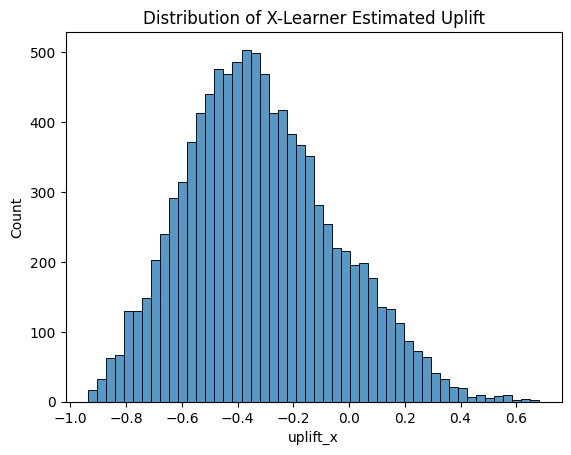

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["uplift_x"], bins=50)
plt.title("Distribution of X-Learner Estimated Uplift")
plt.show()

In [5]:
COST = 10
MARGIN = 60
TARGET_RATIO = 0.3

df_sorted = df.sort_values("uplift_x", ascending=False)

top_k = int(len(df) * TARGET_RATIO)
targeted = df_sorted.head(top_k)

revenue = targeted["outcome"].sum() * MARGIN
cost = len(targeted) * COST

profit_x = revenue - cost

print("X-Learner Profit:", profit_x)

X-Learner Profit: 77640
